2025-04-28 10:23:38.760867: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-28 10:23:38.902610: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-28 10:23:40.982620: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-28 10:23:41.833840: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745835823.048074     373 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745835823.32

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 2679.2646 - val_loss: 1817.2185
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2494.8669 - val_loss: 1813.4766
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2346.8596 - val_loss: 1809.5027
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2183.8425 - val_loss: 1805.1129
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2386.5056 - val_loss: 1800.0970
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2432.2458 - val_loss: 1794.2484
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2117.3823 - val_loss: 1787.7166
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2411.8726 - val_loss: 1780.2672
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2043.9426 - val_loss: 1771.9375
Epoch 10/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1786.5719 - val_loss: 1762.6399
Epoch 11/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2362.3792 - val_loss: 1751.7683
Epoch 12

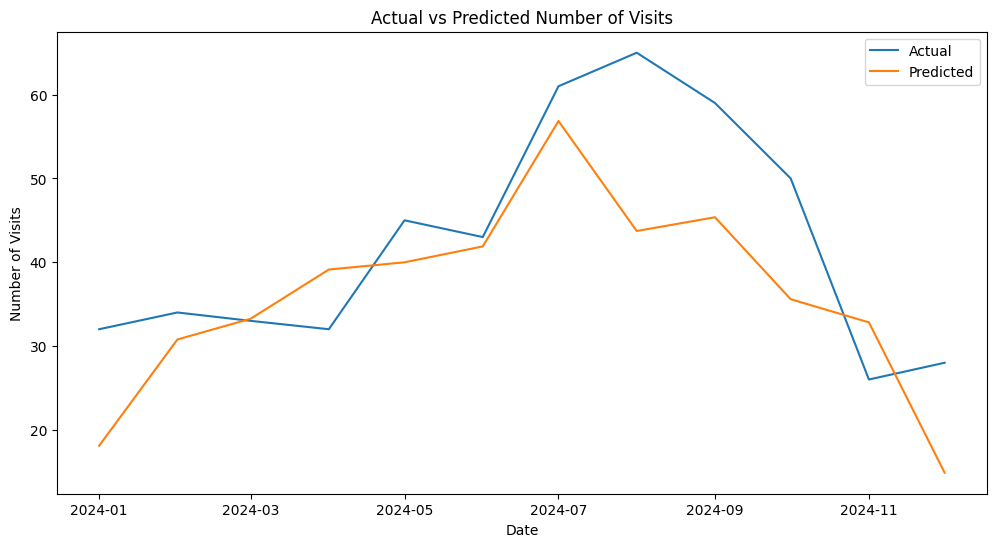

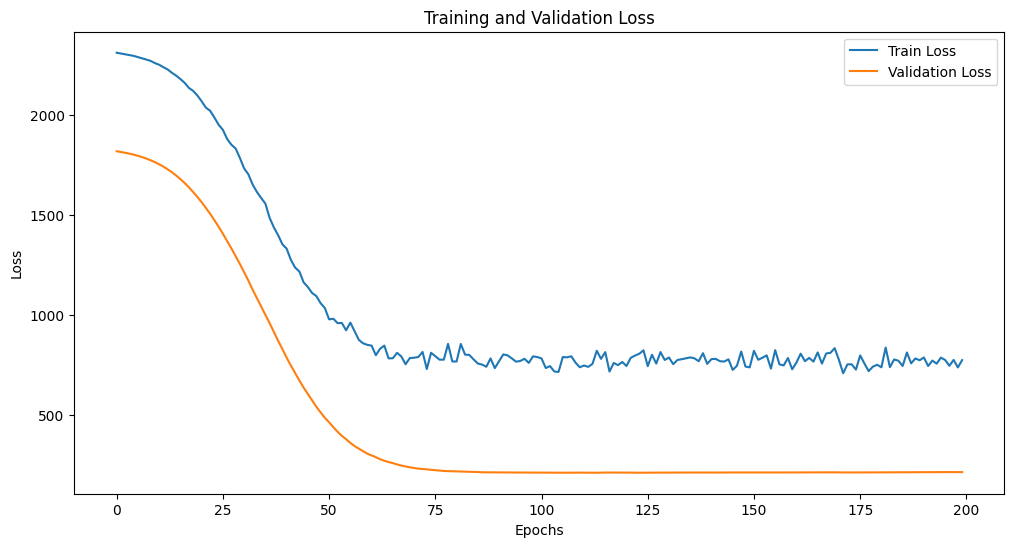

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 加载数据
data = pd.read_csv("../merged_result.csv")

# 将日期列转换为日期格式
data['Visit Date'] = pd.to_datetime(data['Visit Date'])

# 按年份和月份分组，计算每个月的就诊人数总和
data['Year'] = data['Visit Date'].dt.year
data['Month'] = data['Visit Date'].dt.month
monthly_data = data.groupby(['Year', 'Month']).agg({
    'temp': 'mean',
    'humidity': 'mean',
    'precip': 'mean',
    'windspeed': 'mean',
    'uvindex': 'mean',
    'number': 'sum',
    'Visit Date': 'first'  # 保留每个月的第一天作为日期
}).reset_index()

# 分离特征和目标变量
features = monthly_data[['temp', 'humidity', 'precip', 'windspeed', 'uvindex']]
target = monthly_data['number']

# 划分训练集和测试集
train_data = monthly_data[monthly_data['Year'] < 2024]
test_data = monthly_data[monthly_data['Year'] == 2024]

X_train = train_data[['temp', 'humidity', 'precip', 'windspeed', 'uvindex']].values
y_train = train_data['number'].values

X_test = test_data[['temp', 'humidity', 'precip', 'windspeed', 'uvindex']].values
y_test = test_data['number'].values

# 数据标准化
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 将数据转换为 LSTM 所需的 3D 形状 [samples, timesteps, features]
X_train_reshaped = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_reshaped = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# 构建 LSTM 模型
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(1, X_train_scaled.shape[1])))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

# 训练模型
history = model.fit(X_train_reshaped, y_train, epochs=200, batch_size=10, validation_split=0.2, verbose=1)

# 在测试集上进行预测
y_pred = model.predict(X_test_reshaped)

# 反标准化预测结果
y_pred = y_pred.flatten()

# 计算性能指标
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # 计算 RMSE
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # 计算 MAPE
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}%")
print(f"R²: {r2}")

# 可视化预测结果与实际值
plt.figure(figsize=(12, 6))
plt.plot(test_data['Visit Date'], y_test, label='Actual')
plt.plot(test_data['Visit Date'], y_pred, label='Predicted')
plt.xlabel('Date')
plt.ylabel('Number of Visits')
plt.title('Actual vs Predicted Number of Visits')
plt.legend()
plt.show()

# 可视化训练过程中的损失
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

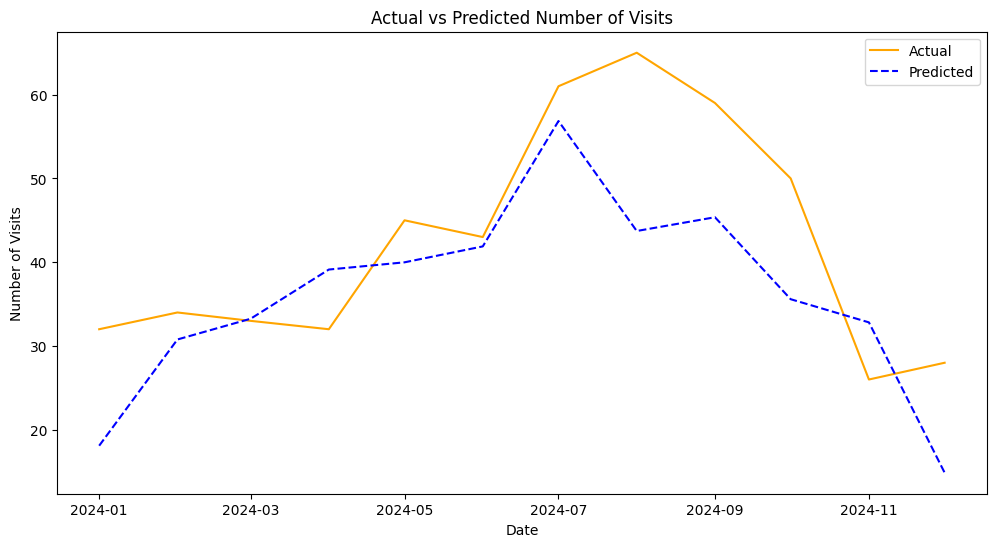

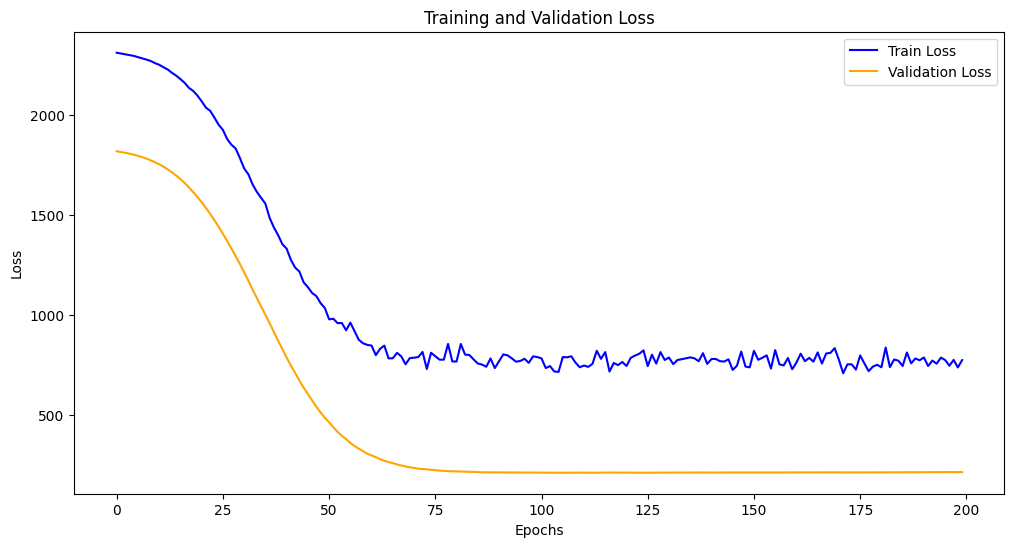

In [3]:
# 可视化预测结果与实际值
plt.figure(figsize=(12, 6))
plt.plot(test_data['Visit Date'], y_test, label='Actual', color='orange', linestyle='-')  # 橙色实线
plt.plot(test_data['Visit Date'], y_pred, label='Predicted', color='blue', linestyle='--')  # 蓝色虚线
plt.xlabel('Date')
plt.ylabel('Number of Visits')
plt.title('Actual vs Predicted Number of Visits')
plt.legend()
plt.show()

# 可视化训练过程中的损失
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss', color='blue', linestyle='-')  # 蓝色实线
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linestyle='-')  # 橙色实线
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [4]:
import os
import pandas as pd

# 检查目标文件夹是否存在，如果不存在则创建
output_folder = "../output"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# 准备保存的数据
output_data = pd.DataFrame({
    'Visit Date': test_data['Visit Date'],
    'Actual': y_test,
    'Predicted': y_pred
})

# 保存为 CSV 文件
output_file_path = os.path.join(output_folder, "actual_vs_predicted.csv")
output_data.to_csv(output_file_path, index=False)

print(f"数据已成功保存到 {output_file_path}")

数据已成功保存到 ../output/actual_vs_predicted.csv
